# Ticket projection diagnostic — `MCAEncoder`

This notebook visualises where each repair ticket lands in the
:class:`KnowledgeGrid`'s embedding space *under the MCA encoder*
(`kata.entities.encoder.mca_encoder.MCAEncoder`).  Compared with the
`HashEncoder` (random hashing into the box), the MCA encoder learns
a structured projection of the categorical features
(`machine_type`, `component_type`) into a continuous space — so
similar repair types should land *close together* in the grid.

Workflow:

1. Build a rich factory (30 unique machines × 4 techs).
2. Roll out for `N_TICKETS` random actions, capturing every
   :class:`RepairRequest` object.
3. **Fit the MCAEncoder** on the captured corpus.
4. Encode every ticket; record embedding + grid cell.
5. Plot the same projections as for the hash encoder:
   continuous-embedding scatter, grid-cell scatter, density heatmap,
   per-signature mapping table, and an animated film of grid fill-up.

The MCA fit diagnostics (`cumulative_inertia`, `eigenvalues`, …)
are printed up front so you can verify the encoder is well-trained
before reading the projection plots.

In [17]:
import sys, pathlib
_here = pathlib.Path.cwd()
for cand in (_here, _here.parent / "src", _here / "src", _here.parent / _here.name):
    if (cand / "kata").exists():
        sys.path.insert(0, str(cand))
        break

import os
os.environ.setdefault("KATA_CONF_PATH", "/dev/null/__no_file__")

import random
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

from ongoing import KnowledgeGrid
from kata.core.config import KATAConfig, ProductConfig
from kata.scenario import ScenarioBuilder
from kata.env import KataEnv
from kata.EntityFactories import create_machine_config, create_technician_config
from kata.entities.encoder.mca_encoder import MCAEncoder

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

## Build the same rich factory as before

In [18]:
SEED = 0
N_TICKETS = 2000      # how many tickets to collect
GRID_SHAPE = (10, 10)

machines = {}
for template, count in [
    ("cnc_weibull",      6),
    ("welder",           6),
    ("conveyor",         6),
    ("assembly_mixed",   3),
    ("assembly_robot",   3),
    ("inspection",       6),
]:
    for i in range(count):
        machines[f"{template}_{i:02d}"] = create_machine_config(template)

technicians = {
    f"{tpl}_1": create_technician_config(tpl, name=f"{tpl}_1")
    for tpl in ("expert", "senior", "generalist", "junior")
}

env_cfg = KATAConfig(
    technicians=technicians,
    machines=machines,
    products={"widget": ProductConfig(
        product_type="widget",
        route=["Conveyor", "CNC", "Welder", "Assembly", "Inspection"],
    )},
)
env_cfg.gym.observation_representation = "structured"
env_cfg.gym.use_mca_encoder = False  # we'll fit our own MCA below
env_cfg.gym.max_episode_steps = N_TICKETS + 100
env_cfg.gym.max_sim_time = 10_000_000.0

env = KataEnv(scenario_factory=lambda: ScenarioBuilder(env_cfg).build(), config=env_cfg.gym)
env.reset(seed=SEED)
print(f"Built env with {len(machines)} machines / {len(technicians)} techs.")

Built env with 30 machines / 4 techs.


## Roll out + capture each `RepairRequest`

We need the actual request objects (not just `(mtype, ctype)`) so the
MCAEncoder can introspect them during `fit`.

In [19]:
random.seed(SEED); np.random.seed(SEED)

captured: list = []  # list of RepairRequest objects in encounter order

n = 0
done = False
while not done and n < N_TICKETS:
    ticket = env.current_request
    a = random.randrange(env.action_space.n)
    if ticket is not None:
        captured.append(ticket)
    obs, _, term, trunc, _ = env.step(a)
    n += 1
    done = term or trunc

print(f"Captured {len(captured)} repair requests over {n} env steps.")

Captured 2000 repair requests over 2000 env steps.


## Fit the MCA encoder + print diagnostics

`is_well_trained()` checks whether the cumulative inertia clears
the default threshold (30 %).  If the fit is degenerate the encoder
falls back to the bounded hash and you'll see that in the plots
below.

In [20]:
encoder = MCAEncoder(grid_shape=GRID_SHAPE, n_components=2)
encoder.fit(captured)
print(encoder.summary())
print()
for key, val in encoder.fit_diagnostics.items():
    if isinstance(val, list):
        print(f"  {key}: {[round(float(v), 4) for v in val]}")
    else:
        print(f"  {key}: {val}")

MCAEncoder(n_requests=2000, unique_combos=13, n_components=2, explained=[50.6%, 49.4%], cumulative=100.0%, well_trained=True)

  n_requests: 2000
  n_unique_feature_tuples: 13
  n_columns_used: 2
  n_components_fit: 2
  eigenvalues: [0.9921, 0.9694]
  explained_inertia: [0.5058, 0.4942]
  cumulative_inertia: 1.0


## Project every ticket through the fitted encoder

In [21]:
# Throwaway KnowledgeGrid: only used to call ``embedding_to_coords``
# so we can show the cell the bump lands on alongside the embedding.
probe_grid = KnowledgeGrid(
    shape=GRID_SHAPE,
    propagation_sigma=1.0, transmission_factor=0.5,
    learning_rate=0.1, methods=["propagation"],
)

rows = []
for idx, ticket in enumerate(captured):
    machine = getattr(ticket, "machine", None)
    mt = str(getattr(machine, "mtype", "?"))
    ci = ticket.get_failed_component_info() if hasattr(ticket, "get_failed_component_info") else None
    ct = str((ci or {}).get("component_type", "none"))

    embedding = encoder.encode(ticket)
    grid_coord = probe_grid.embedding_to_coords(embedding)

    rows.append({
        "n": idx + 1,
        "machine_type": mt,
        "component_type": ct,
        "signature": f"{mt}/{ct}",
        "embed_x": float(embedding[0]),
        "embed_y": float(embedding[1]),
        "grid_i": int(grid_coord[0]),
        "grid_j": int(grid_coord[1]),
    })

df = pd.DataFrame(rows)
print(f"Projected {len(df)} tickets.")
df.head(10)

Projected 2000 tickets.


,n,machine_type,component_type,signature,embed_x,embed_y,grid_i,grid_j
0,1,Inspection,sensor,Inspection/sensor,16.008744,100.00000,1,9
1,2,Conveyor,mechanical,Conveyor/mechanical,100.000000,25.64765,9,2
2,3,Conveyor,mechanical,Conveyor/mechanical,100.000000,25.64765,9,2
3,4,Conveyor,mechanical,Conveyor/mechanical,100.000000,25.64765,9,2
4,5,Conveyor,mechanical,Conveyor/mechanical,100.000000,25.64765,9,2
5,6,CNC,spindle,CNC/spindle,0.000000,0.00000,0,0
6,7,Inspection,sensor,Inspection/sensor,16.008744,100.00000,1,9
7,8,Conveyor,mechanical,Conveyor/mechanical,100.000000,25.64765,9,2
8,9,CNC,spindle,CNC/spindle,0.000000,0.00000,0,0
9,10,Conveyor,mechanical,Conveyor/mechanical,100.000000,25.64765,9,2


## Continuous-embedding scatter

MCA places categories close in the projected space when they
co-occur with similar patterns.  Distinct signatures should sit at
distinct points; clusters of nearby points are the encoder telling
you *those repair types are similar*.

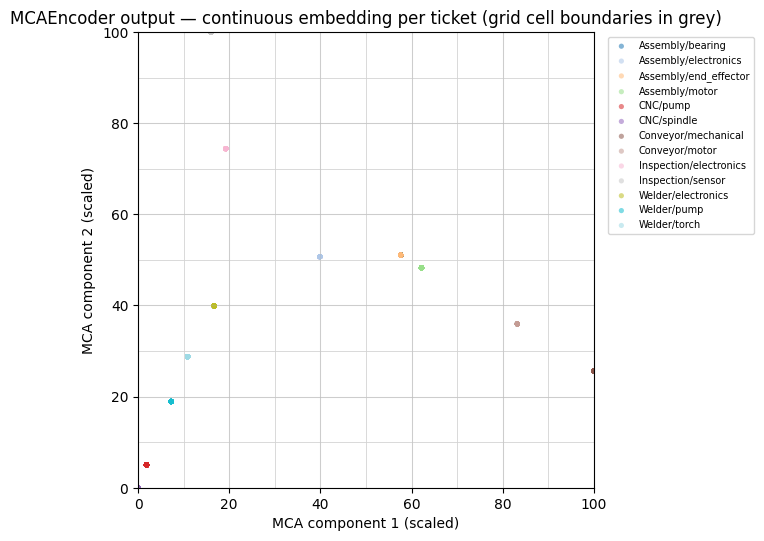

In [22]:
bounds = encoder.embedding_bounds  # (2, 2): [[lo_x, hi_x], [lo_y, hi_y]]

def _scatter_embedding(df):
    sigs = sorted(df["signature"].unique())
    cmap = plt.get_cmap("tab20", max(len(sigs), 1))
    colour_for = {s: cmap(i % cmap.N) for i, s in enumerate(sigs)}

    fig, ax = plt.subplots(figsize=(7, 7))
    for sig in sigs:
        sub = df[df["signature"] == sig]
        ax.scatter(sub["embed_x"], sub["embed_y"],
                   s=14, alpha=0.55, label=sig,
                   color=colour_for[sig], edgecolors="none")
    # Grid cell boundaries
    for k in range(GRID_SHAPE[1] + 1):
        x = bounds[0, 0] + (bounds[0, 1] - bounds[0, 0]) * k / GRID_SHAPE[1]
        ax.axvline(x, color="lightgrey", lw=0.6, zorder=0)
    for k in range(GRID_SHAPE[0] + 1):
        y = bounds[1, 0] + (bounds[1, 1] - bounds[1, 0]) * k / GRID_SHAPE[0]
        ax.axhline(y, color="lightgrey", lw=0.6, zorder=0)
    ax.set(
        xlim=(bounds[0, 0], bounds[0, 1]),
        ylim=(bounds[1, 0], bounds[1, 1]),
        xlabel="MCA component 1 (scaled)", ylabel="MCA component 2 (scaled)",
        title="MCAEncoder output — continuous embedding per ticket "
              f"(grid cell boundaries in grey)",
    )
    ax.set_aspect("equal")
    ax.legend(fontsize=7, bbox_to_anchor=(1.02, 1.0), loc="upper left")
    plt.tight_layout(); plt.show()

_scatter_embedding(df)

## Grid-cell scatter

After `embedding_to_coords`, each ticket lands on a discrete cell.
With the MCA encoder, cells are determined by the learned projection
rather than uniform hashing.

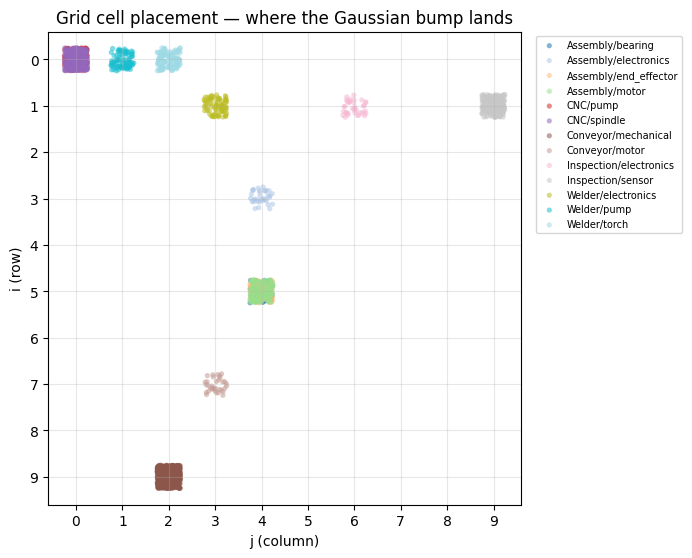

In [23]:
def _scatter_grid_cells(df):
    sigs = sorted(df["signature"].unique())
    cmap = plt.get_cmap("tab20", max(len(sigs), 1))
    colour_for = {s: cmap(i % cmap.N) for i, s in enumerate(sigs)}

    fig, ax = plt.subplots(figsize=(7, 7))
    jx = np.random.default_rng(0).uniform(-0.25, 0.25, size=len(df))
    jy = np.random.default_rng(1).uniform(-0.25, 0.25, size=len(df))
    for sig in sigs:
        sub = df[df["signature"] == sig]
        idx = sub.index.to_numpy()
        ax.scatter(sub["grid_j"].to_numpy() + jx[idx],
                   sub["grid_i"].to_numpy() + jy[idx],
                   s=14, alpha=0.55, label=sig,
                   color=colour_for[sig], edgecolors="none")
    ax.set(
        xlim=(-0.6, GRID_SHAPE[1] - 0.4),
        ylim=(GRID_SHAPE[0] - 0.4, -0.6),  # invert y so (0,0) is top-left like imshow
        xticks=range(GRID_SHAPE[1]), yticks=range(GRID_SHAPE[0]),
        xlabel="j (column)", ylabel="i (row)",
        title="Grid cell placement — where the Gaussian bump lands",
    )
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7, bbox_to_anchor=(1.02, 1.0), loc="upper left")
    plt.tight_layout(); plt.show()

_scatter_grid_cells(df)

## Density heatmap — grid cells

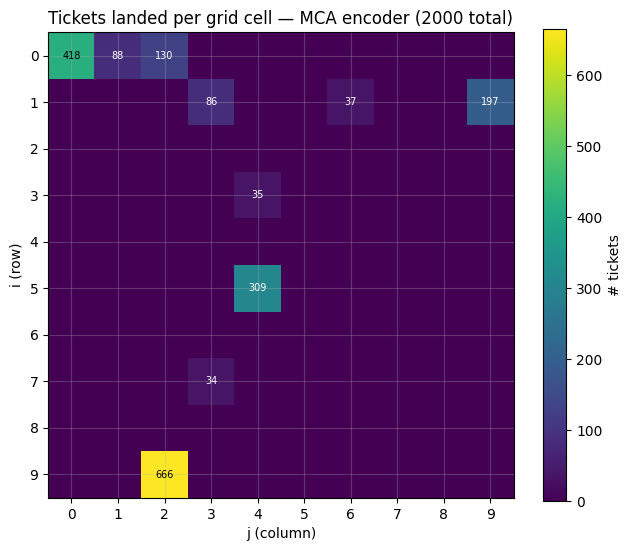


=> 10 / 100 cells used  (10.0% of the grid)
=> top cell holds 666 / 2000 tickets  (33.3%)


In [24]:
heatmap = np.zeros(GRID_SHAPE, dtype=np.int64)
for i, j in zip(df["grid_i"], df["grid_j"]):
    heatmap[int(i), int(j)] += 1

fig, ax = plt.subplots(figsize=(6.5, 6))
im = ax.imshow(heatmap, cmap="viridis", aspect="equal")
ax.set(xticks=range(GRID_SHAPE[1]), yticks=range(GRID_SHAPE[0]),
       xlabel="j (column)", ylabel="i (row)",
       title=f"Tickets landed per grid cell — MCA encoder ({len(df)} total)")
for i in range(GRID_SHAPE[0]):
    for j in range(GRID_SHAPE[1]):
        v = heatmap[i, j]
        if v > 0:
            ax.text(j, i, str(v), ha="center", va="center", fontsize=7,
                    color="white" if v < heatmap.max() * 0.5 else "black")
fig.colorbar(im, ax=ax, shrink=0.85, label="# tickets")
plt.tight_layout(); plt.show()

n_cells_used = int((heatmap > 0).sum())
n_cells_total = heatmap.size
print(f"\n=> {n_cells_used} / {n_cells_total} cells used  "
      f"({100 * n_cells_used / n_cells_total:.1f}% of the grid)")
print(f"=> top cell holds {heatmap.max()} / {len(df)} tickets  "
      f"({100 * heatmap.max() / max(1, len(df)):.1f}%)")

## Mapping table — signature → embedding & cell

In [25]:
mapping = (
    df.groupby("signature", as_index=False)
      .agg(
          n_tickets=("n", "count"),
          embedding=("embed_x", lambda s: f"({s.iloc[0]:.2f}, {df.loc[s.index[0], 'embed_y']:.2f})"),
          grid=("grid_i", lambda s: f"({s.iloc[0]}, {df.loc[s.index[0], 'grid_j']})"),
      )
      .sort_values("n_tickets", ascending=False)
)
collisions = mapping.groupby("grid").size().reset_index(name="signatures_on_this_cell")
collisions = collisions.sort_values("signatures_on_this_cell", ascending=False)

print("Per-signature mapping (embedding -> grid cell):")
print(mapping.to_string(index=False))
print()
print("Collisions per grid cell (signatures sharing the same cell):")
print(collisions.to_string(index=False))

Per-signature mapping (embedding -> grid cell):
             signature  n_tickets       embedding   grid
   Conveyor/mechanical        666 (100.00, 25.65) (9, 2)
           CNC/spindle        245    (0.00, 0.00) (0, 0)
     Inspection/sensor        197 (16.01, 100.00) (1, 9)
              CNC/pump        173    (1.85, 5.00) (0, 0)
          Welder/torch        130  (10.89, 28.75) (0, 2)
        Assembly/motor        125  (62.20, 48.24) (5, 4)
 Assembly/end_effector        114  (57.63, 51.04) (5, 4)
           Welder/pump         88   (7.25, 18.92) (0, 1)
    Welder/electronics         86  (16.71, 39.90) (1, 3)
      Assembly/bearing         70  (57.63, 51.04) (5, 4)
Inspection/electronics         37  (19.25, 74.40) (1, 6)
  Assembly/electronics         35  (39.90, 50.70) (3, 4)
        Conveyor/motor         34  (83.21, 35.95) (7, 3)

Collisions per grid cell (signatures sharing the same cell):
  grid  signatures_on_this_cell
(5, 4)                        3
(0, 0)                      

## Film — grid placement as tickets accumulate

In [26]:
FRAME_STEP = max(1, len(df) // 40)

checkpoints = list(range(FRAME_STEP, len(df) + 1, FRAME_STEP))
if checkpoints[-1] != len(df):
    checkpoints.append(len(df))

cumulative = []
running = np.zeros(GRID_SHAPE, dtype=np.int64)
prev = 0
for cp in checkpoints:
    for k in range(prev, cp):
        running[int(df.iloc[k]["grid_i"]), int(df.iloc[k]["grid_j"])] += 1
    cumulative.append(running.copy())
    prev = cp

vmax = max(int(running.max()), 1)

fig, ax = plt.subplots(figsize=(6.5, 6))
im = ax.imshow(cumulative[0], cmap="viridis", vmin=0, vmax=vmax,
               aspect="equal", animated=True)
ax.set(xticks=range(GRID_SHAPE[1]), yticks=range(GRID_SHAPE[0]),
       xlabel="j (column)", ylabel="i (row)")
title = ax.set_title("")
fig.colorbar(im, ax=ax, shrink=0.85, label="# tickets")

def update(frame_idx):
    im.set_data(cumulative[frame_idx])
    title.set_text(f"MCA — tickets so far: {checkpoints[frame_idx]} / {len(df)}")
    return [im, title]

anim = animation.FuncAnimation(fig, update, frames=len(cumulative),
                               interval=200, blit=False)
plt.close(fig)
HTML(anim.to_jshtml())

## What this notebook tells you

* The **continuous-embedding scatter** should show MCA placing
  similar signatures close to each other (e.g. all CNC failures
  near each other, all motor failures near each other).
* If `cumulative_inertia` (printed up top) is below `0.30` the
  encoder is in fallback mode (bounded hash) — the projection is
  random, not learned.
* The **grid-cell scatter** + heatmap show how much the discretisation
  preserves the MCA-learned structure.  A *good* MCA fit lights up
  several cells; signatures that legitimately project to the same
  cell are encoded as "similar enough" by the MCA.
* If only one or two cells are bright AND the inertia is high, the
  MCA found one dominant axis of variation — usually because one
  feature (e.g. `machine_type`) dwarfs the others.  Pass a custom
  feature set to ``_features_from_request`` to rebalance.